# Beruch Consulting Mission #003 : Prédiction du diabète (HealthCo)

Objectif : construire un modèle de Machine Learning capable de prédire le diabète à partir de facteurs démographiques, cliniques et comportementaux.

Client (fictif) : HealthCo, organisme de santé publique.

Problématique : peut-on prédire le diabète d'un patient à partir de ses caractéristiques non diagnostiques (âge, mode de vie, antécédents, corpulence), 
et quels facteurs pèsent le plus ?

Cas fictif réalisé dans le cadre d'un défi data portfolio. Données publiques de santé (synthétiques).



## 1 Import des librairies et du dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/beruc/Downloads/diabetes_dataset.csv")
df.head(10)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,...,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,...,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,...,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,...,33,132,98,116,172,5.70,6.90,26.7,Type 2,1
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,...,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0


## 2 Inspection des données

On commence par comprendre la structure du jeu de données : dimensions, types, aperçu et statistiques descriptives.

In [2]:
# Dimensions
print("Dimensions :", df.shape)

# Structure et types
df.info()

Dimensions : (100000, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  s

In [3]:
# Statistiques descriptives des variables numériques
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [4]:
# Aperçus variés
print(df.tail(5))
print(df.sample(5))
print(df.columns.tolist())

       age  gender ethnicity education_level  income_level employment_status  \
99995   46    Male     Other        Graduate  Upper-Middle        Unemployed   
99996   41  Female     White        Graduate        Middle          Employed   
99997   57  Female     Black       No formal  Upper-Middle          Employed   
99998   47  Female     Black      Highschool  Lower-Middle           Retired   
99999   52  Female     White    Postgraduate        Middle          Employed   

      smoking_status  alcohol_consumption_per_week  \
99995         Former                             1   
99996          Never                             3   
99997         Former                             4   
99998          Never                             3   
99999          Never                             1   

       physical_activity_minutes_per_week  diet_score  ...  hdl_cholesterol  \
99995                                 136         8.3  ...               45   
99996                               

## Analyse des valeurs manquantes

In [19]:
# Nombre et pourcentage de valeurs manquantes par colonne
manquants = pd.DataFrame({
    "manquants": df.isnull().sum(),
    "pourcentage": (df.isnull().mean() * 100).round(2)
}).sort_values(by="manquants", ascending=False)

print(manquants)

                                    manquants  pourcentage
age                                         0          0.0
waist_to_hip_ratio                          0          0.0
diabetes_stage                              0          0.0
diabetes_risk_score                         0          0.0
hba1c                                       0          0.0
insulin_level                               0          0.0
glucose_postprandial                        0          0.0
glucose_fasting                             0          0.0
triglycerides                               0          0.0
ldl_cholesterol                             0          0.0
hdl_cholesterol                             0          0.0
cholesterol_total                           0          0.0
heart_rate                                  0          0.0
diastolic_bp                                0          0.0
systolic_bp                                 0          0.0
bmi                                         0          0

## 3 Analyse exploratoire (EDA)

## Distribution des variables numériques

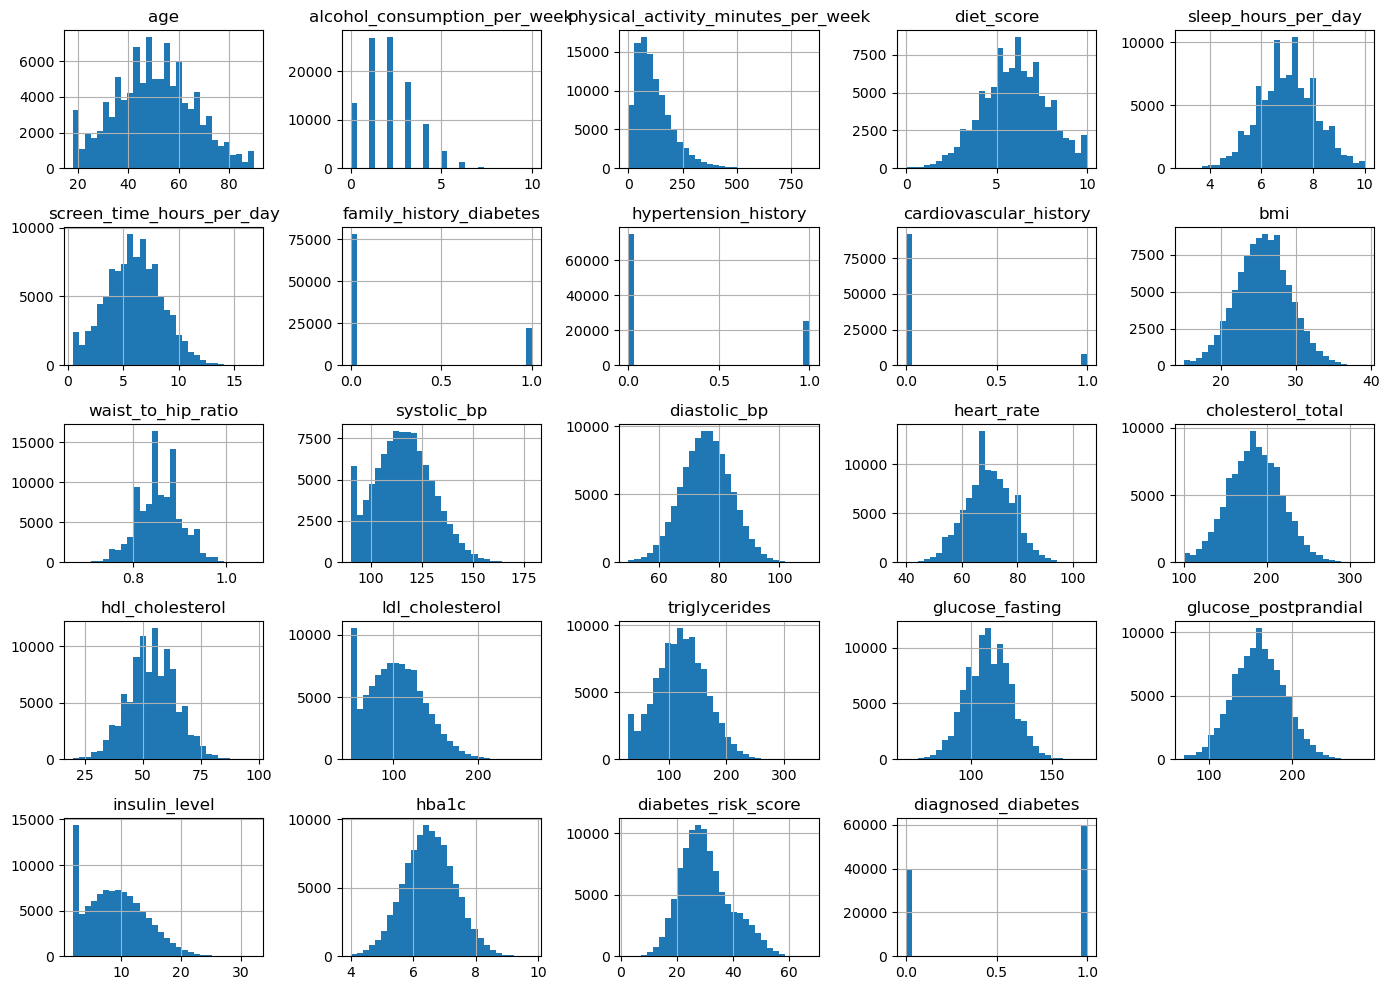

In [6]:
# Histogrammes de toutes les variables numériques
df.select_dtypes(include="number").hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

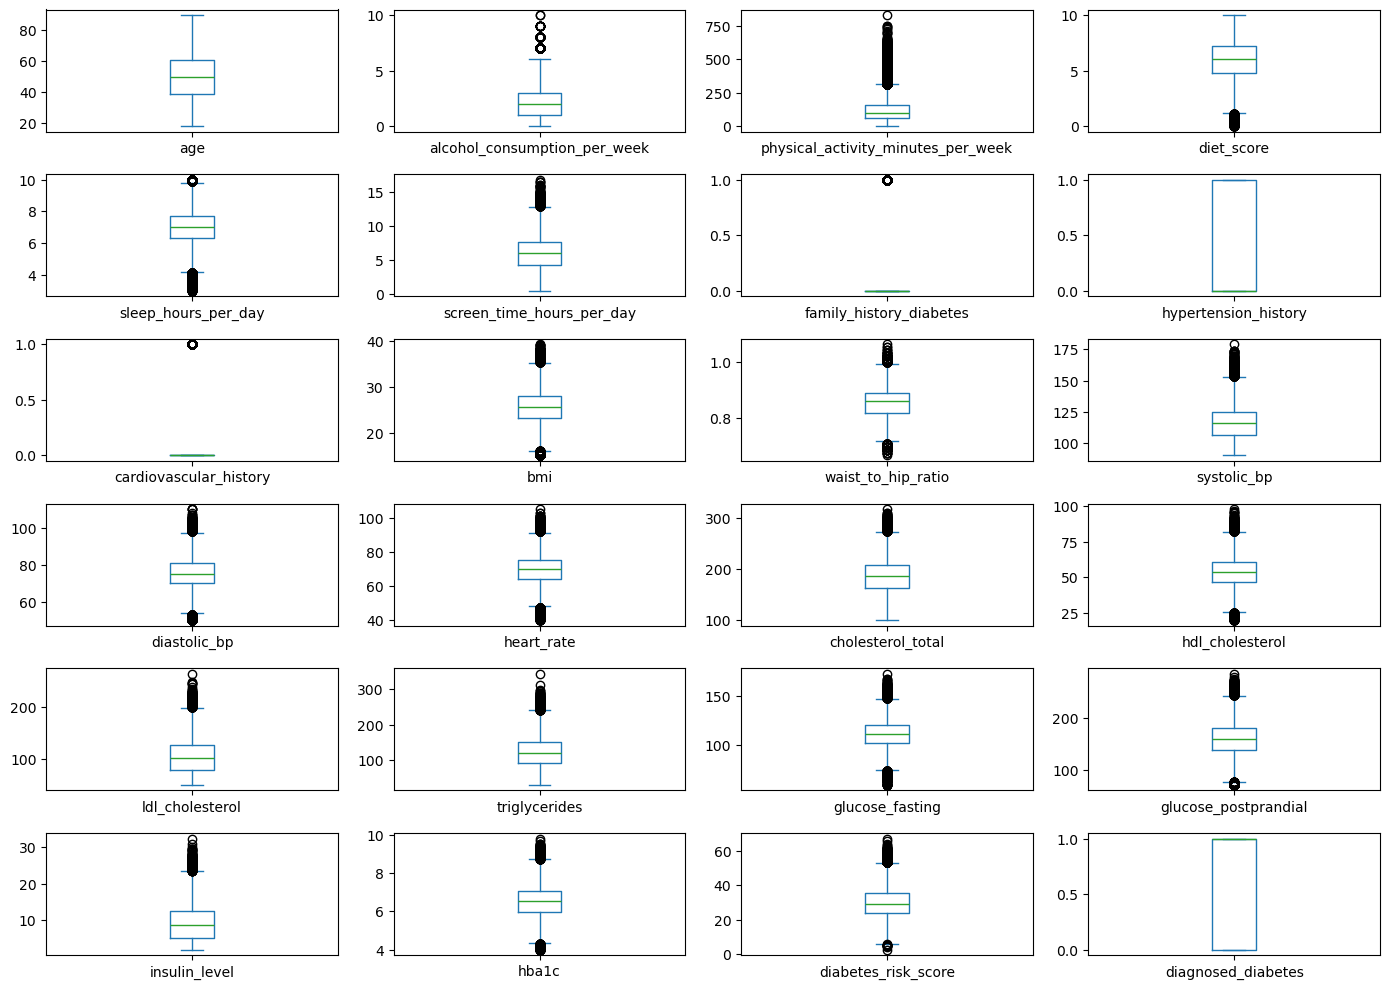

In [7]:
# Boxplots pour repérer les valeurs extrêmes (outliers)
df.select_dtypes(include="number").plot(
    kind="box", subplots=True, layout=(6, 4), figsize=(14, 10)
)
plt.tight_layout()
plt.show()

## Matrice de corrélation

On visualise les corrélations linéaires entre variables numériques. Un masque triangulaire évite la redondance (la matrice étant symétrique).

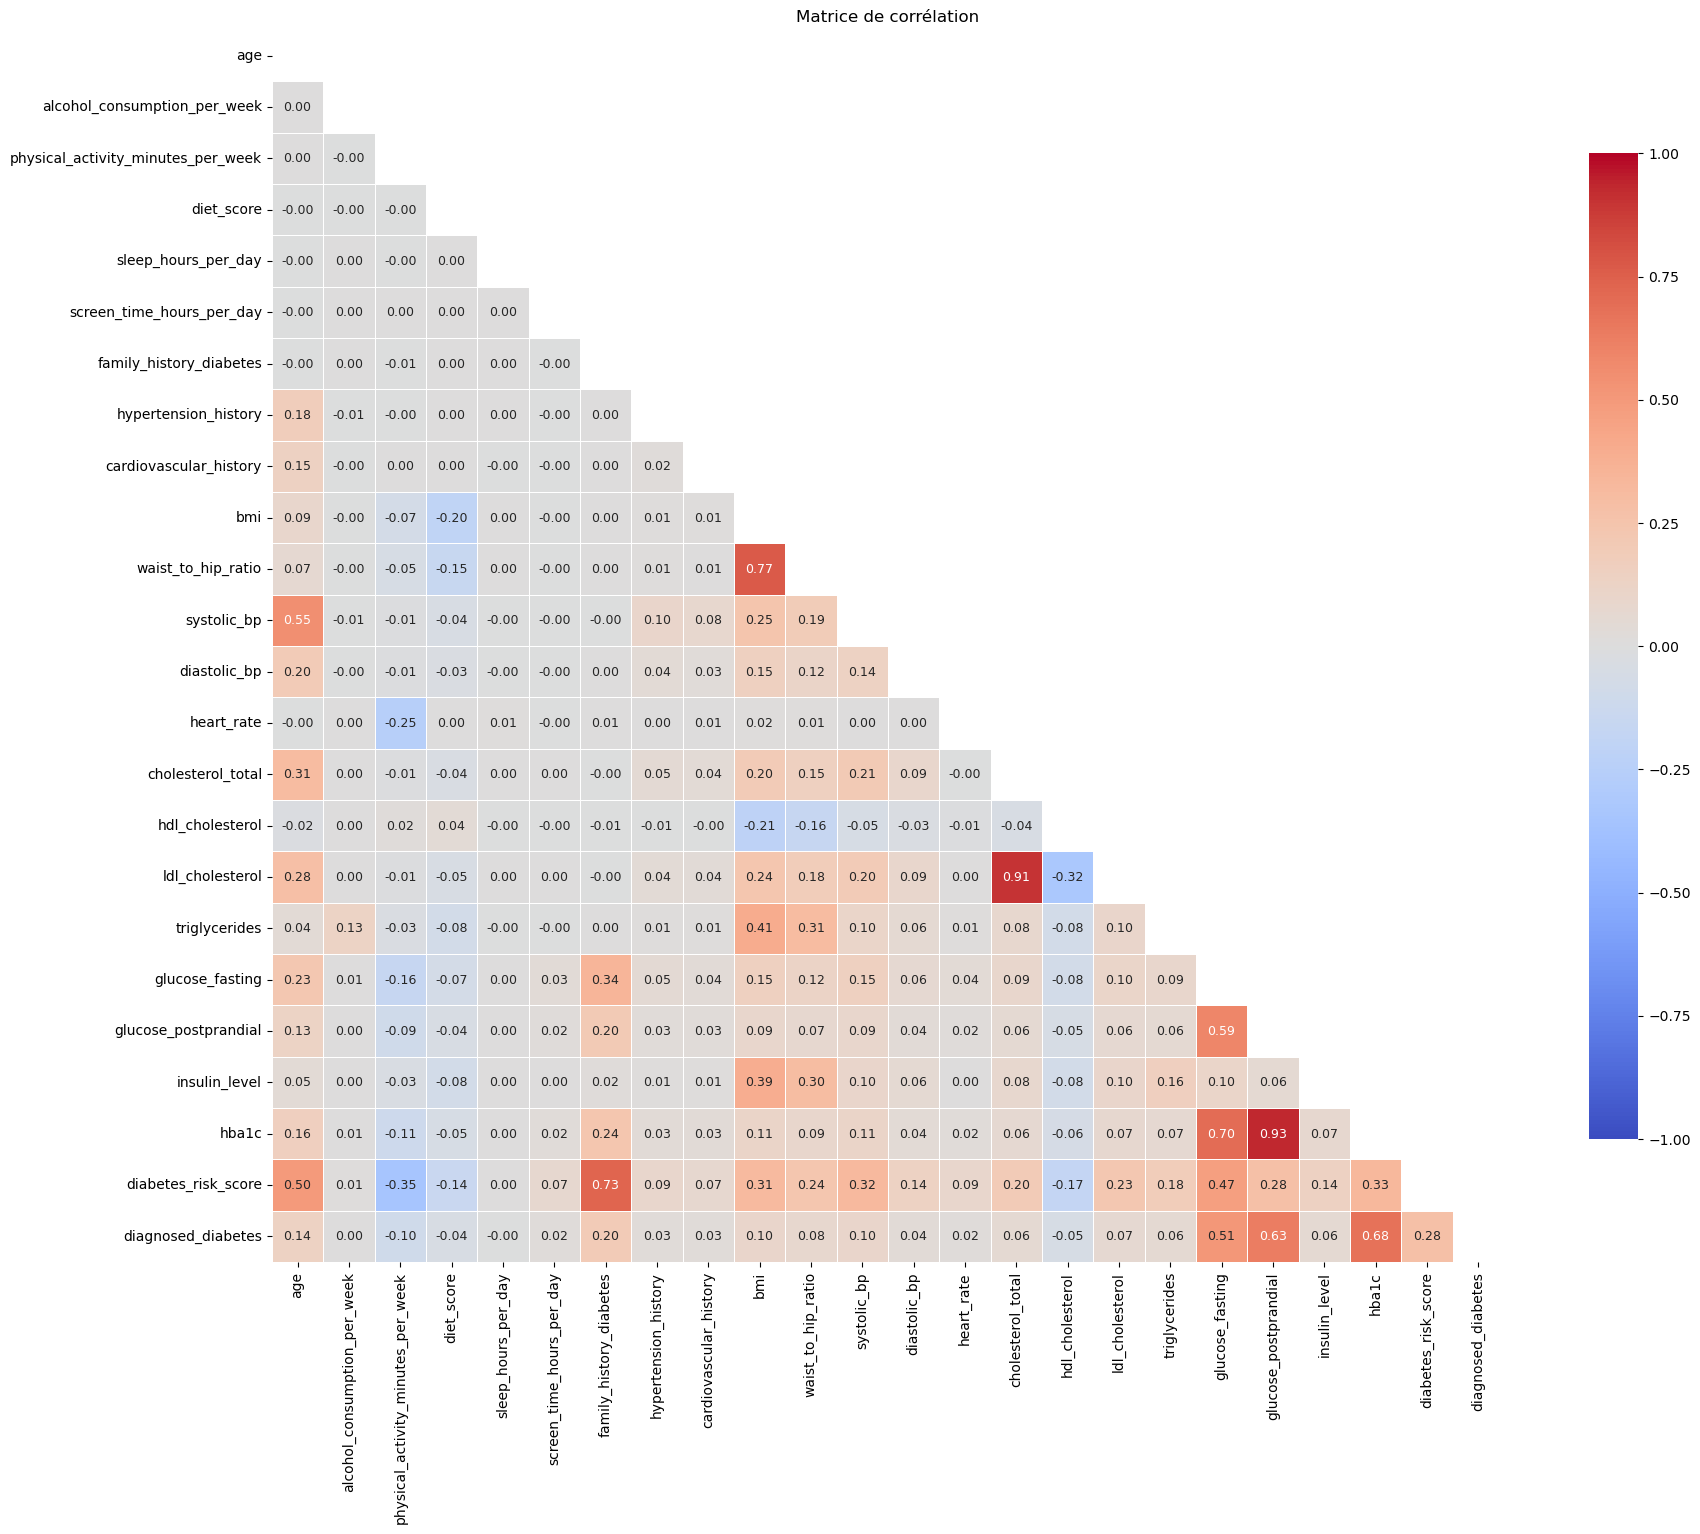

In [8]:
corr = df.select_dtypes(include="number").corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(22, 16))
sns.heatmap(
    corr, mask=mask, fmt=".2f", annot=True, cmap="coolwarm",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}, annot_kws={"size": 9}
)
plt.title("Matrice de corrélation")
plt.show()

## 4 Préparation des données

## Séparation X / y et garde-fou méthodologique

Point clé du projet : on exclut volontairement les marqueurs diagnostiques du diabète :
glucose_fasting, glucose_postprandial, hba1c, insulin_level, diabetes_risk_score, diabetes_stage.

Pourquoi ? Ces variables définissent ou mesurent le diabète. Les utiliser pour le prédire reviendrait à un raisonnement circulaire (data leakage) : le modèle aurait un score artificiellement élevé mais serait inutile en pratique. On ne conserve que des facteurs de risque exploitables en amont d'un diagnostic.

In [9]:
y = df["diagnosed_diabetes"]

x = df.drop(columns=[
    "diagnosed_diabetes",      # la cible
    "glucose_fasting",         # marqueur diagnostique
    "glucose_postprandial",    # marqueur diagnostique
    "hba1c",                   # marqueur diagnostique
    "insulin_level",           # marqueur clinique lié au glucose
    "diabetes_risk_score",     # score dérivé de la cible
    "diabetes_stage"           # autre formulation de la cible
])

print("Variables conservées :", x.shape[1])
print(x.columns.tolist())

Variables conservées : 24
['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']


## Séparation des variables catégorielles et numériques

Les deux types de variables ne se préparent pas de la même façon : les numériques seront standardisées, les catégorielles encodées (one-hot).

In [10]:
x_numerique = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
x_categorielle = x.select_dtypes(include=["object"]).columns.tolist()

print("Catégorielles :", x_categorielle)
print("Numériques :", x_numerique)

Catégorielles : ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']
Numériques : ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']


## Construction du pipeline de préprocessing

On utilise un ColumnTransformer pour appliquer le bon traitement à chaque type de variable, le tout encapsulé dans un Pipeline scikit-learn (approche propre
et reproductible) :
- Numériques :  StandardScaler (centrage-réduction)
- Catégorielles : OneHotEncoder (avec handle_unknown="ignore" pour gérer d'éventuelles catégories inconnues)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Pipelines par type de variable
nume_pipeline = Pipeline(steps=[("scaler", StandardScaler())])
cate_pipeline = Pipeline(steps=[("one", OneHotEncoder(handle_unknown="ignore"))])

# Préprocesseur global
preprocessor = ColumnTransformer(transformers=[
    ("cat", cate_pipeline, x_categorielle),
    ("nume", nume_pipeline, x_numerique)
])

## Séparation train / test

80 % des données pour l'entraînement, 20 % pour l'évaluation. random_state=42 garantit la reproductibilité.

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Train :", x_train.shape, "| Test :", x_test.shape)

Train : (80000, 24) | Test : (20000, 24)


## 5 Modélisation

## Fonction d'évaluation

Une fonction réutilisable qui entraîne un modèle et affiche ses performances sur le train ET le test (pour détecter un éventuel surapprentissage).

In [20]:
from sklearn.metrics import (
    roc_auc_score, classification_report, accuracy_score,
    precision_recall_curve, confusion_matrix
)

def evaluation_model(model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_pred_train = model.predict(x_train)

    print("Accuracy train :", round(accuracy_score(y_train, y_pred_train), 3))
    print("Accuracy test  :", round(accuracy_score(y_test, y_pred), 3))
    print("\nClassification report :\n", classification_report(y_test, y_pred))

## Modèle 1 : Régression logistique (modèle de référence)

On commence par un modèle simple et interprétable. class_weight="balanced" corrige le déséquilibre des classes (60 % / 40 %) en 
pénalisant davantage les erreurs sur la classe minoritaire.

In [15]:
model_lr = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

evaluation_model(model_lr, x_train, x_test, y_train, y_test)

Accuracy train : 0.606
Accuracy test  : 0.602

Classification report :
               precision    recall  f1-score   support

           0       0.51      0.67      0.57      8077
           1       0.71      0.56      0.63     11923

    accuracy                           0.60     20000
   macro avg       0.61      0.61      0.60     20000
weighted avg       0.63      0.60      0.61     20000



## Modèle 2 : Random Forest (comparaison)

Un modèle plus complexe, pour vérifier si davantage de sophistication améliore les performances.

In [17]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, max_depth=5, min_samples_leaf=5,
        min_samples_split=10, max_features="sqrt",
        class_weight="balanced", random_state=42
    ))
])

evaluation_model(model_rf, x_train, x_test, y_train, y_test)

Accuracy train : 0.604
Accuracy test  : 0.596

Classification report :
               precision    recall  f1-score   support

           0       0.50      0.67      0.57      8077
           1       0.71      0.54      0.62     11923

    accuracy                           0.60     20000
   macro avg       0.61      0.61      0.60     20000
weighted avg       0.63      0.60      0.60     20000



# Observation : la régression logistique et le Random Forest donnent des performances quasi identiques (environ 60 % d'accuracy). Quand un modèle simple et un modèle complexe convergent vers le même résultat, c'est le signe que la limite vient des données, pas du modèle.

## 6 Optimisation des hyperparamètres (GridSearchCV)

On cherche les meilleurs réglages de la régression logistique par validation croisée. On optimise le recall : en santé, ne pas rater un patient à risque (limiter les faux négatifs) est prioritaire.

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": ["balanced"]
}

grid = GridSearchCV(model_lr, param_grid, cv=5, scoring="recall", n_jobs=-1)
grid.fit(x_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score recall (CV) :", round(grid.best_score_, 3))

best_model = grid.best_estimator_
evaluation_model(best_model, x_train, x_test, y_train, y_test)

Meilleurs paramètres : {'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Meilleur score recall (CV) : 0.562
Accuracy train : 0.606
Accuracy test  : 0.602

Classification report :
               precision    recall  f1-score   support

           0       0.51      0.67      0.57      8077
           1       0.71      0.56      0.63     11923

    accuracy                           0.60     20000
   macro avg       0.61      0.61      0.60     20000
weighted avg       0.63      0.60      0.61     20000



# Résultat : l'optimisation n'apporte aucun gain notable. Troisième confirmation que le plafond de performance (environ 60 %) tient à la nature synthétique des données, et non au modèle ou à son réglage.

## 7 Interprétation des coefficients

La régression logistique permet de quantifier l'effet de chaque facteur via ses coefficients, convertis en odds ratios (exp(coef)) :
- odds ratio > 1 : le facteur augmente le risque
- odds ratio < 1 : le facteur diminue le risque

In [23]:
modele_final = best_model.named_steps["model"]
noms_variables = best_model.named_steps["preprocessing"].get_feature_names_out()
coefficients = modele_final.coef_[0]

coef_df = pd.DataFrame({
    "variable": noms_variables,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
}).sort_values(by="coefficient", ascending=False)

print("=== Facteurs qui AUGMENTENT le risque ===")
print(coef_df.head(10))
print("\n=== Facteurs qui DIMINUENT le risque ===")
print(coef_df.tail(10))

=== Facteurs qui AUGMENTENT le risque ===
                           variable  coefficient  odds_ratio
30    nume__family_history_diabetes     0.464437    1.591119
24                        nume__age     0.279061    1.321887
2                 cat__gender_Other     0.154923    1.167568
33                        nume__bmi     0.104956    1.110662
41              nume__triglycerides     0.045397    1.046444
29  nume__screen_time_hours_per_day     0.042054    1.042950
6              cat__ethnicity_Other     0.039059    1.039832
10   cat__education_level_No formal     0.037717    1.038438
12           cat__income_level_High     0.032707    1.033248
14   cat__income_level_Lower-Middle     0.030102    1.030559

=== Facteurs qui DIMINUENT le risque ===
                                    variable  coefficient  odds_ratio
15                  cat__income_level_Middle    -0.003686    0.996321
7                       cat__ethnicity_White    -0.004449    0.995561
25        nume__alcohol_consumption

### Visualisation des facteurs de risque

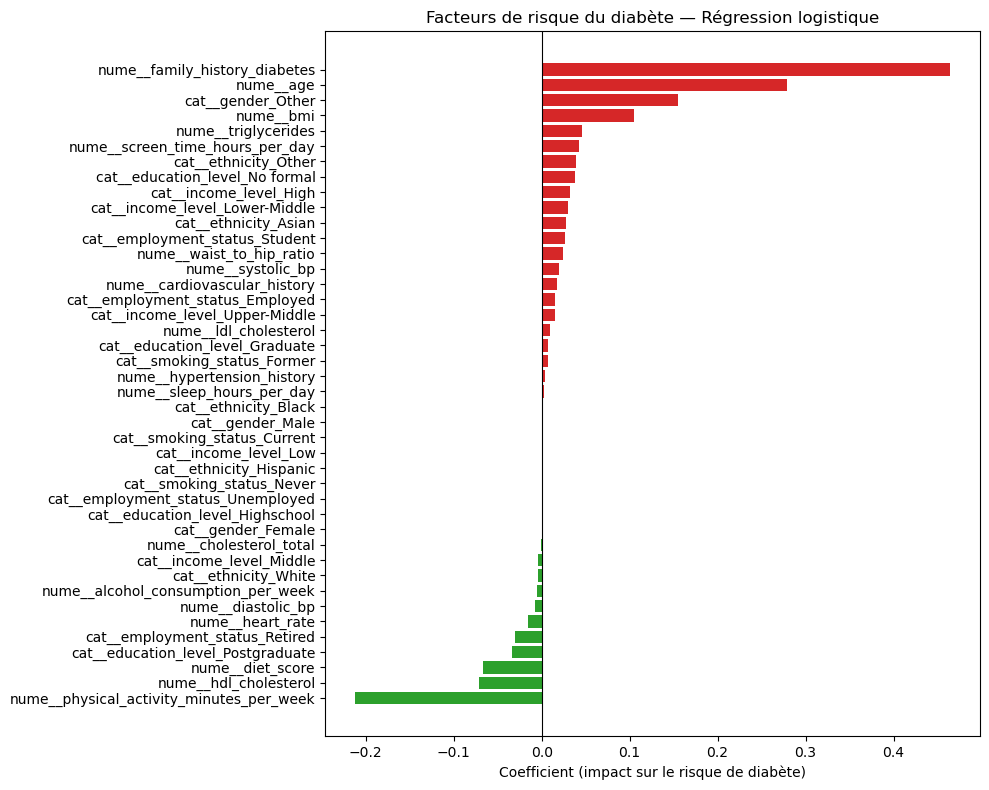

In [25]:
coef_plot = coef_df.sort_values(by="coefficient", ascending=True)
couleurs = ["#2ca02c" if c < 0 else "#d62728" for c in coef_plot["coefficient"]]
plt.figure(figsize=(10, 8))
plt.barh(coef_plot["variable"], coef_plot["coefficient"], color=couleurs)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (impact sur le risque de diabète)")
plt.title("Facteurs de risque du diabète — Régression logistique")
plt.tight_layout()
plt.show()

## 8 Conclusion

Performance : environ 60 % d'accuracy, sans surapprentissage (train , test).

Le constat clé :  trois expériences convergentes :
1- Régression logistique vs Random Forest  même performance.
2- Ajout / retrait de l'insuline  même performance.
3- Optimisation des hyperparamètres  aucun gain.

- Le plafond de performance vient de la nature synthétique des données (signal prédictif faible), pas du modèle. Ce résultat est cohérent avec l'analyse Power BI de la Mission #002.

Facteurs de risque dominants (cohérents avec la Mission #002) : antécédents familiaux, âge, IMC.

# Recommandations pour HealthCo :
- Cibler le dépistage sur les patients cumulant antécédents familiaux, âge élevé et surpoids.
- Ne pas substituer ce modèle à un diagnostic clinique (signal trop faible).
- Investir dans des données réelles et mieux renseignées pour un outil réellement prédictif.

Limites : données synthétiques, corrélation ≠ causalité, marqueurs diagnostiques exclus volontairement (choix méthodologique assumé).

# Beruch Ibala — défi data portfolio (30 jours).